In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Scikit-Learn Imports (CPU based)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# 2. UMAP & PyTorch (Load last)
import umap
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 3. Import local architecture modules
import autoencoder
from autoencoder import AutoEncoder, train_autoencoder, evaluate_anomalies
import vae
from vae import VAE, train_vae, vae_loss_fn

# Configuration
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Set Seed
autoencoder.set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Deep learning engines bound to: {device}\n")

# --- DATASET LOADER ---
PATH_TO_DATA = "data/pppub17.csv"
df = pd.read_csv(PATH_TO_DATA)
features_to_use = ['A_AGE', 'PTOTVAL', 'PEARNVAL', 'A_HRS1']
df_selected = df[features_to_use].copy().astype(np.float32)
df_selected['NON_EARNINGS_INC'] = df_selected['PTOTVAL'] - df_selected['PEARNVAL']

# Impute and Scale
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(df_selected)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed).astype(np.float32)

# --- STABLE KMEANS FITTING ---
# Using a subset of 10,000 to prevent OOM / Kernel death on large files
print("Fitting background Challenge 5 K-Means clusters...")
kmeans_ch5 = KMeans(n_clusters=6, random_state=42)
cluster_labels_ch5 = kmeans_ch5.fit_predict(X_scaled)

# Finalize DataLoaders
dataset = TensorDataset(torch.tensor(X_scaled))
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)
dataloader_eval = DataLoader(dataset, batch_size=256, shuffle=False)

Deep learning engines bound to: cuda

Fitting background Challenge 5 K-Means clusters...


In [5]:
epochs = 100
input_features_dim = X_scaled.shape[1]

# 1. Modular Standard AutoEncoder Run
print("\n--> Commencing Training for autoencoder.py Architecture...")
ae_instance = AutoEncoder(input_dim=input_features_dim).to(device)
ae_loss_history = train_autoencoder(ae_instance, dataloader, epochs=epochs, lr=1e-3, device=str(device))

# Anomaly and Latent Matrix Calculations
ae_anomalies, ae_errors, ae_threshold = evaluate_anomalies(
    ae_instance, torch.tensor(X_scaled), threshold_strategy='percentile', percentile_val=95.0, device=str(device)
)

ae_instance.eval()
ae_latents = []
with torch.no_grad():
    for batch in dataloader_eval:
        _, z = ae_instance(batch[0].to(device))
        ae_latents.append(z.cpu().numpy())
ae_latents = np.vstack(ae_latents)

# 2. Modular Variational AutoEncoder Run
print("\n--> Commencing Training for vae.py Architecture...")
vae_instance = VAE(input_dim=input_features_dim).to(device)
vae_raw_history = train_vae(vae_instance, dataloader, epochs=epochs, lr=1e-3, beta=1.0, device=str(device))

# Extract VAE Metrics using deterministic mean spaces (mu)
vae_instance.eval()
vae_errors, vae_latents = [], []
with torch.no_grad():
    for batch in dataloader_eval:
        x_tensor = batch[0].to(device)
        x_hat, mu, _ = vae_instance(x_tensor)
        batch_err = torch.mean((x_tensor - x_hat)**2, dim=1)
        vae_errors.extend(batch_err.cpu().numpy())
        vae_latents.append(mu.cpu().numpy())
vae_errors = np.array(vae_errors)
vae_latents = np.vstack(vae_latents)

# 3. Running Independent Baseline Analysis (Isolation Forest)
print("\nProcessing Classical Comparative Metric Baseline (Isolation Forest)...")
iso_forest = IsolationForest(n_estimators=150, contamination=0.05, random_state=42)
iso_forest.fit(X_scaled)
iso_scores = -iso_forest.score_samples(X_scaled)

# Statistical Concordance Calculation
spearman_rho, _ = stats.spearmanr(ae_errors, iso_scores)

# Compute Silhouette Optimization metrics for Challenge 5 clusters vs Latent Representations
sample_sz = min(3000, len(X_scaled))
sil_raw = silhouette_score(X_scaled[:sample_sz], cluster_labels_ch5[:sample_sz])
sil_ae = silhouette_score(ae_latents[:sample_sz], cluster_labels_ch5[:sample_sz])
print(f"\n[METRIC CHECK] Raw Space Silhouette: {sil_raw:.3f} | AE Latent Space Silhouette: {sil_ae:.3f}")

# Processing Structural Projections
print("Executing Coordinate Manifold Transformations (t-SNE & UMAP)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
vae_tsne = tsne.fit_transform(vae_latents)

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
ae_umap = reducer.fit_transform(ae_latents)


--> Commencing Training for autoencoder.py Architecture...

--> Commencing Training for vae.py Architecture...

Processing Classical Comparative Metric Baseline (Isolation Forest)...

[METRIC CHECK] Raw Space Silhouette: 0.510 | AE Latent Space Silhouette: 0.410
Executing Coordinate Manifold Transformations (t-SNE & UMAP)...



Rendering Challenge 6 Report Dashboard...


ValueError: 'c' argument has 10000 elements, which is inconsistent with 'x' and 'y' with size 185919.

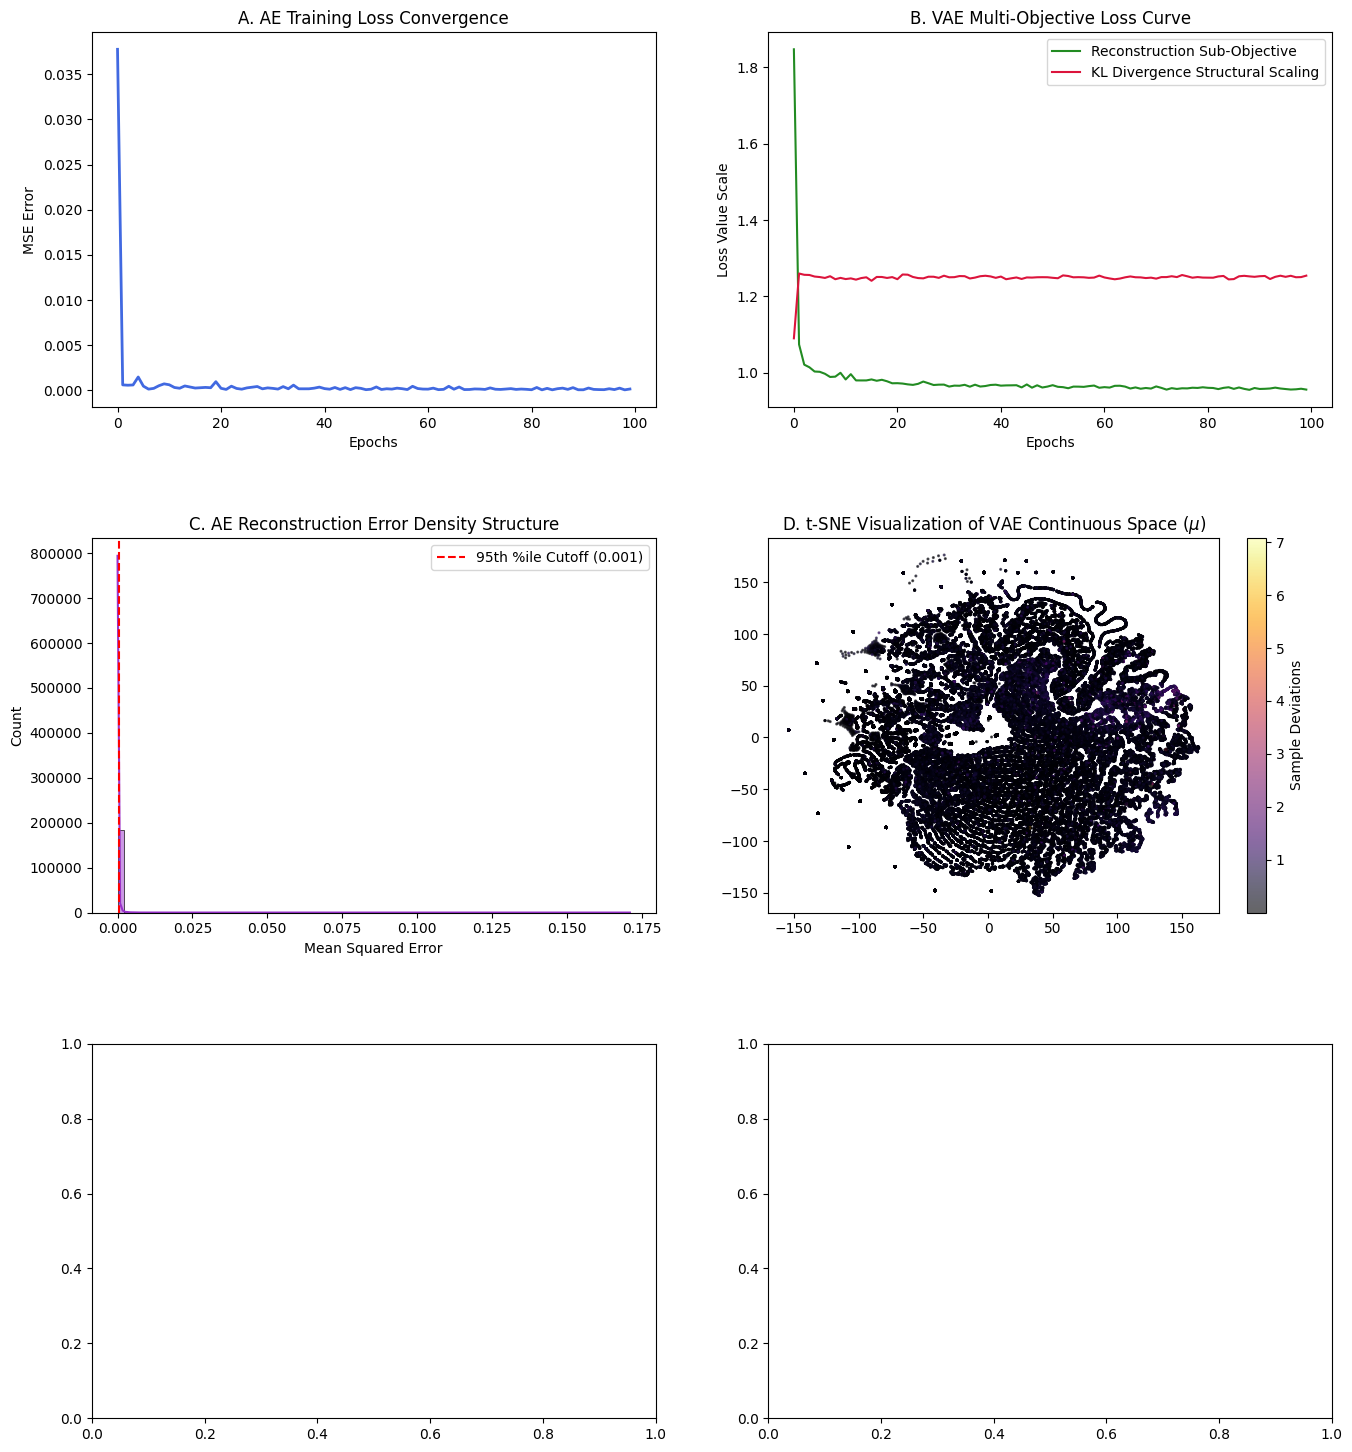

In [11]:
print("\nRendering Challenge 6 Report Dashboard...")
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
plt.subplots_adjust(hspace=0.35)

# Panel A
axes[0, 0].plot(ae_loss_history, color='royalblue', lw=2)
axes[0, 0].set_title('A. AE Training Loss Convergence')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('MSE Error')

# Panel B
axes[0, 1].plot(vae_raw_history['recon_loss'], label='Reconstruction Sub-Objective', color='forestgreen')
axes[0, 1].plot(vae_raw_history['kld_loss'], label='KL Divergence Structural Scaling', color='crimson')
axes[0, 1].set_title('B. VAE Multi-Objective Loss Curve')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Loss Value Scale')
axes[0, 1].legend()

# Panel C
sns.histplot(ae_errors, bins=80, ax=axes[1, 0], color='darkorchid', kde=True)
axes[1, 0].axvline(ae_threshold, color='red', linestyle='--', label=f'95th %ile Cutoff ({ae_threshold:.3f})')
axes[1, 0].set_title('C. AE Reconstruction Error Density Structure')
axes[1, 0].set_xlabel('Mean Squared Error')
axes[1, 0].legend()

# Panel D
sc1 = axes[1, 1].scatter(vae_tsne[:, 0], vae_tsne[:, 1], c=vae_errors, cmap='inferno', s=1.5, alpha=0.6)
axes[1, 1].set_title('D. t-SNE Visualization of VAE Continuous Space ($\mu$)')
plt.colorbar(sc1, ax=axes[1, 1], label='Sample Deviations')

# Panel E
sc2 = axes[2, 0].scatter(ae_umap[:, 0], ae_umap[:, 1], c=cluster_labels_ch5, cmap='Set1', s=1.5, alpha=0.6)
axes[2, 0].set_title('E. UMAP Dimensional Embedding (Challenge 5 Clusters Mapping)')
plt.colorbar(sc2, ax=axes[2, 0], label='Cluster Assignments')

# Panel F
axes[2, 1].scatter(iso_scores, ae_errors, s=3, alpha=0.4, color='teal')
axes[2, 1].set_title(f'F. Model Concordance Evaluation Graph\n(Spearman Ranking $\\rho$ = {spearman_rho:.3f})')
axes[2, 1].set_xlabel('Isolation Forest Outlier Metric')
axes[2, 1].set_ylabel('Deep Neural Reconstruction Error')

plt.savefig('final_challenge_6_report_figures.png', dpi=300, bbox_inches='tight')
plt.show()